# MLE example: Exponential PDF

* Consider an experiment in which you measure the decay time $t$ of a set of nuclei of the same specie and you want to estimate the average lifetime $\tau$
* You will use an exponential pdf to model the decay:
$$ f(t;\tau) = \frac{1}{\tau}e^{-t/\tau}$$
* Your goal is to find an estimator $\hat\tau$ using the MLE method

## Analytic derivation
* The likelihood function is:
$$L(\tau)=\prod_{i=1}^n \frac{1}{\tau} e^{-t_i / \tau}$$
* To find the maximum it's easier to work with the log:
$$
\ln L(\tau)=\sum_{i=1}^n \ln f\left(t_i ; \tau\right)=\sum_{i=1}^n\left(\ln \frac{1}{\tau}-\frac{t_i}{\tau}\right)
$$
* The we just set the derivative to 0 to find the MLE:
$$\frac{\partial \ln L(\tau)}{\partial \tau} = 0$$
$$ \Rightarrow \hat\tau = \frac{1}{n}\sum_{i=1}^{n} t_i$$
* The MLE for $\hat\tau$ is simply the average $t$ in this case.

## Numerical derivation

In [54]:
# generate a data sample to represent our measurements
from scipy.stats import expon
import numpy as np

true_tau = 10 # expectation value
n = 10000
t_i_measured = expon.rvs(scale=true_tau, size=n)

In [55]:
# define the log likelihood function
def loglikelihood(tau, t_i):
    return np.sum(np.log(1/tau * np.exp(-t_i/tau)))

If the loglikelyhood is parabolical, the likelyhood is gaussian

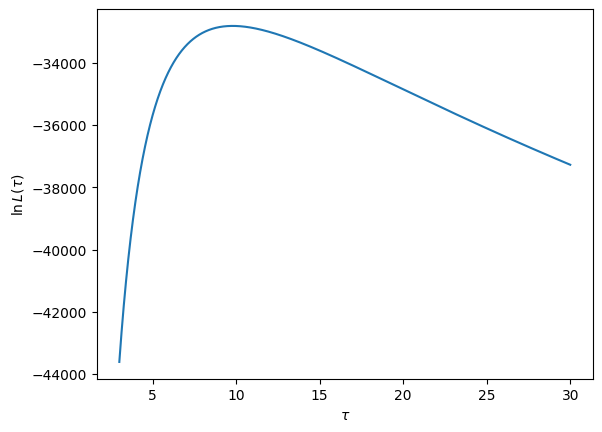

In [56]:
# calculate the likelihood for a range of tau
import matplotlib.pyplot as plt
tau_vals = np.linspace(3, 30, 10000)
logL_vals = [loglikelihood(tau, t_i_measured) for tau in tau_vals]

plt.plot(tau_vals, logL_vals)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\ln L(\tau)$')
plt.show()
#@title { vertical-output: true}

In [57]:
# now find the value of tau that maximises the log likelihood
max_logL = np.max(logL_vals)
print(f'The maximum value of the logL is {max_logL}')
tauhat = tau_vals[np.argmax(logL_vals)]
print(f'The MLE for tau is {tauhat:.4f}')

The maximum value of the logL is -32811.85277007833
The MLE for tau is 9.7885


In [58]:
# find maximum using the minimiser from scipy.optimise
from scipy.optimize import minimize

# let's define the negative log-likelihood since it's a miniser
def negloglikelihood(tau, t_i):
    return -loglikelihood(tau, t_i)

# minimisation step
result = minimize(negloglikelihood, x0=1, args=(t_i_measured,))
tauhat = result.x[0]
print(f'The MLE for tau is {tauhat:.4f}')

The MLE for tau is 9.7883


In [59]:
# Compare the obtained result to the mean value
tau_mean = np.mean(t_i_measured)
print(f'The mean value of t is {tau_mean:.4f}')

The mean value of t is 9.7883


## Properties of the MLE estimator $\hat\tau$

### Analytic derivation of bias and variance

* Remember that for the exponential distribution:
$$ E[t] = \tau~~~{\rm and}~~~V[t] = \tau^2$$
* What are the bias and variance of the MLE $\hat\tau$?
$$
E[\hat{\tau}]=E\left[\frac{1}{n} \sum_{i=1}^n t_i\right]=\frac{1}{n} \sum_{i=1}^n E\left[t_i\right]=\tau \quad \longrightarrow \quad b=E[\hat{\tau}]-\tau=0
$$

$$
V[\hat{\tau}]=V\left[\frac{1}{n} \sum_{i=1}^n t_i\right]=\frac{1}{n^2} \sum_{i=1}^n V\left[t_i\right]=\frac{\tau^2}{n} \quad \longrightarrow \quad \sigma_{\hat{\tau}}=\frac{\tau}{\sqrt{n}}
$$

### MC method for bias and variance

In [60]:
# We can generate 1000 pseudo-experiments

tauhat_list = []
for i in range(1000):
  # generate
  t_i = expon.rvs(scale=true_tau, size=n)
  # get MLE from minimising the negative log-likelihood
  result = minimize(negloglikelihood, x0=1, args=(t_i,))
  # save the result
  tauhat_list.append(result.x[0])


The mean value of the MLE is 9.9991
The standard deviation of the MLE is 0.1015


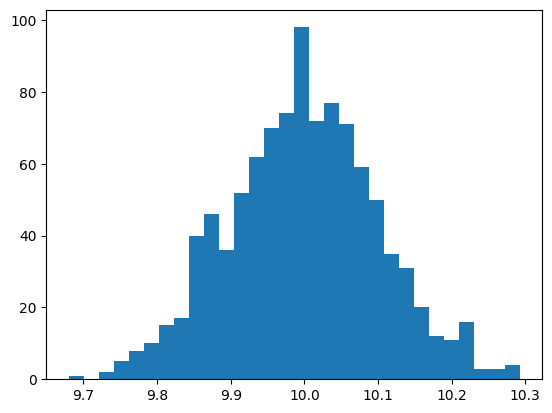

In [61]:
# how are the tauhat for the 1000 pseudo-experiments distributed?
plt.hist(tauhat_list, bins=30);

mean_val = np.mean(tauhat_list)
stddev = np.std(tauhat_list)
print(f'The mean value of the MLE is {mean_val:.4f}')
print(f'The standard deviation of the MLE is {stddev:.4f}')
#@title { vertical-output: true}

In [62]:
# compare to the analytic formulas
print(f'The expectation value for the MLE is {true_tau}')
print(f'The expectation value for the variance of the MLE is {true_tau/np.sqrt(n)}')

The expectation value for the MLE is 10
The expectation value for the variance of the MLE is 0.1


# Bootstrapping method

In the real world, **we often only have one dataset** ($t\_i$). We cannot easily re-run a particle physics experiment or clinical trial.

**Bootstrapping** is a statistical technique that allows to simulate "pseudo-experiments" using only the data we already have.

### How it works:
1. **Resampling with Replacement:** We draw a random sample of size $n$ from our original dataset, allowing the same data points to be picked more than once (sampling with replacement).
2. **Calculate the MLE:** We calculate our Maximum Likelihood Estimate for this new sample.
3. **Repeat:** We repeat this process thousands of times, storing the MLE from each pseudo-experiment.
4. **Analyze:** The distribution of these bootstrapped MLEs closely approximates the true PDF of our estimator. In particular, we can use it to get the **variance** of the MLE.

In [63]:
# Let's generate pseudo-experiments by bootstrapping our original dataset t_i
B = 1000 # Number of bootstrap iterations (pseudo-experiments)
bootstrap_mles = []

# 1. Run the bootstrap loop
for _ in range(B):
    # Draw a random sample of the same size as t_i, WITH replacement
    t_i_bootstrap = np.random.choice(t_i, size=len(t_i), replace=True)
    # we take a set of data of the same size but with replacements

    # Calculate the MLE for this pseudo-experiment (the sample mean)
    result = minimize(negloglikelihood, x0=1, args=(t_i_bootstrap,))
    tauhat_bootstrap = result.x[0]

    # Store the result
    bootstrap_mles.append(tauhat_bootstrap)

The mean value of the MLE is 9.9894
The standard deviation of the MLE is 0.0992


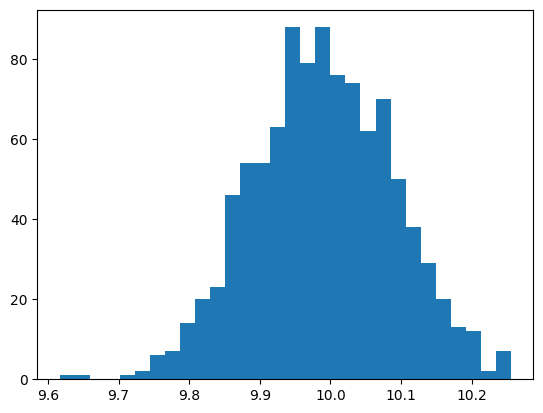

In [64]:
# how are the tauhat for the 1000 pseudo-experiments distributed?
plt.hist(bootstrap_mles, bins=30);

mean_val = np.mean(bootstrap_mles)
stddev = np.std(bootstrap_mles)
print(f'The mean value of the MLE is {mean_val:.4f}')
print(f'The standard deviation of the MLE is {stddev:.4f}')
#@title { vertical-output: true}

# The Minimum Variance Bound (information inequality)

It can be shown that there is a lower bound on the variance of **any** estimator.

For a single parameter the Minimum Variance Bound (MVB) is:
$$
V[\hat{\theta}] \geq\left(1+\frac{\partial b}{\partial \theta}\right)^2 / E\left[-\frac{\partial^2 \ln L}{\partial \theta^2}\right]
$$
where $b$ is the bias $b=E[\hat\theta]-\theta$.

An estimator whose **variance equals the MVB** is said to be efficient.

# Asymptotic properties of MLEs

Suppose we have an independent identically distributed (i.i.d.) dataset of size $n$. The MLE has some important asymptotic properties in the limit of $n\to\infty$.

However, some **regularity conditions** have to hold, icluding:
* the parameter cannot be on the edge of the parameter space
* the boundaries of the data space cannot depend on the parameter
* $\ln L(\theta)$ must be differentiable and the only solution to $\partial \ln L/\partial\theta=0$ is $\hat\theta$

For large $n$, the likelihood function approaches a Gaussian shape. Consequently, the log-likelihood becomes parabolic near the MLE.

The MLEs asymptotic properties are:
1. **The MLE is asymptotically consistent** (it converges to the true parameter value)
2. **The MLE is asymptotically unbiased** (the bias $b$ goes to 0 as $n\to\infty$)
3. **The MLE is asymptotically efficient** (the variance approaches the MVB)
  $$
\lim _{n \rightarrow \infty} V[\hat{\theta}]=-\frac{1}{E\left[\frac{\partial^2 \ln L}{\partial \theta^2}\right]}
  $$
4. **The MLE's distribution becomes Gaussian**

# Implementating a MLE with `iminuit`

In [65]:
# we can use the pdf defined in scipy.stats instead of the analytic form
import scipy.stats as stats
def model_expon(x, tau):
  return stats.expon.pdf(x, scale=tau)

### 1. Building the NLL with iminuit

To use `iminuit`, we need to define our probability density function (PDF). `iminuit` provides a convenient `UnbinnedNLL` cost function that automatically calculates the Negative Log-Likelihood (NLL) for unbinned data.

Remember that MINUIT minimizes functions, which is why we minimize the NLL instead of maximizing the likelihood directly.

In [66]:
# Build the Unbinned NLL using our measured data and the PDF
from iminuit.cost import UnbinnedNLL
my_nll = UnbinnedNLL(t_i_measured, model_expon)

### 2. Performing the Fit
We initialize the `iminuit` object by passing our cost function and an initial guess for our parameter $\tau$. Since $\tau$ represents a physical lifetime, it must be strictly positive, so we can also set physical boundaries before running the minimization.

The main minimization algorithm in `iminuit` is called **MIGRAD**. It efficiently explores the parameter space to find the exact minimum of the NLL.

In [67]:
from iminuit import Minuit
# Initialize Minuit with a starting guess (e.g., tau = 5.0)
m = Minuit(my_nll, tau=5.0)

# Set a lower limit because lifetime cannot be negative
m.limits["tau"] = (0.001, None)

# Run the MIGRAD minimization algorithm
m.migrad()
#@title { vertical-output: true}

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.562e+04                  │              Nfcn = 27               │
│ EDM = 4.54e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ tau  │   9.79    │   0.10    │            │            │  0.001  │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────┐
│     │     tau │
├─────┼─────────┤
│ tau │ 0.00958 │
└─────┴─────────┘

* FCN = value of the likelyhood at the minimum with a factor -2
* EDM = estimated distance from minimum
* good convergence of the minimization process

* Errors are calculated via the **MVB formula**


Unbinned NLL makes the plot using the pdf and setting the plot to be weighted with the number of data

### 3. Estimating Symmetric Errors: HESSE
After running `migrad()`, `Minuit` automatically estimates the uncertainty by calculating the inverse of the second derivative of the NLL evaluated at the minimum. (parabolic approx)
$$
\sigma_{\hat{\tau}}^2=\left.\left(\frac{\partial^2 \mathrm{NLL}}{\partial \tau^2}\right)^{-1}\right|_{\tau=\hat{\tau}}
$$

This is done by the **HESSE** algorithm (in several dimensions, this is called the Hessian matrix).
* **Assumption:** It assumes that the NLL curve is perfectly parabolic around the minimum, which is equivalent to assuming the parameter's probability distribution is perfectly Gaussian.


In [68]:
# you can access the results of the fit from the Minuit object
print(f"Best fit tau = {m.values['tau']:.3f}")
print(f"HESSE error  = ± {m.errors['tau']:.3f}")

Best fit tau = 9.788
HESSE error  = ± 0.098


### 4. The graphical method: MINOS

You have seen that $\sigma_{\hat\theta}$ can be obtained from plotting the logL and calculating where the logL changes by $\frac{1}{2}$:

In the cases where the NLL curve is not perfectly parabolic, this graphical method can be used to estimate an asymmetric confidence interval.

The **MINOS** algorithm does this for you. Instead on relying on the second derivative of the likelihood at the minimum, it explicitly scans the NLL curve on both sides of the minimum to find the parameter values where the NLL increases by 0.5 (or actually where 2NLL increases by 1.0).

MINOS yields **asymmetric errors** ($\Delta \tau_+$ and $\Delta \tau_-$) which reflect the true shape of the likelihood function.

In [69]:
m.minos();
# Display the nice summary table in Jupyter
display(m.merrors)

# Extract and print the values programmatically
tau_minos_minus = m.merrors["tau"].lower
tau_minos_plus  = m.merrors["tau"].upper

print(f"Best fit tau = {m.values['tau']:.3f}")
print(f"MINOS lower error (Δtau-) = {tau_minos_minus:.3f}")
print(f"MINOS upper error (Δtau+) = +{tau_minos_plus:.3f}")
#@title { vertical-output: true}

┌──────────┬───────────────────────┐
│          │          tau          │
├──────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘

Best fit tau = 9.788
MINOS lower error (Δtau-) = -0.097
MINOS upper error (Δtau+) = +0.099


### 5. Visualizing the Likelihood Profile

We can plot the 1D profile of the cost function around the minimum to visually understand why the errors might be asymmetric. `iminuit` has a built-in method to draw this curve and visualize the MINOS limits.

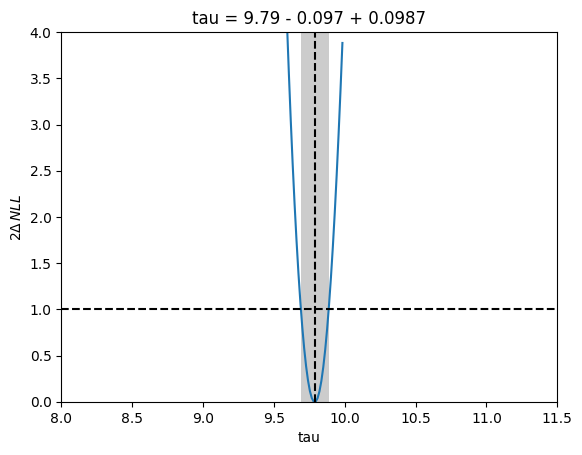

In [70]:
# Plot the profile of the NLL for the parameter 'tau'
# This plots the NLL curve and draws the 1-sigma intervals found by MINOS
m.draw_mnprofile("tau");
plt.hlines(1, 8, 11.5, linestyles='dashed', color='black');
plt.xlim(8, 11.5)
plt.ylim(0, 4)
plt.ylabel(r'$2\Delta\, NLL$')

plt.show()
#@title { vertical-output: true}

# Generalization to N parameters

In most real-world physics problems, our probability density function (PDF) depends on multiple parameters rather than just one. Let's define a parameter vector $\vec{\theta} = (\theta_1, \theta_2, \dots, \theta_N)$.

The log-likelihood function for a dataset of $n$ independent measurements $\vec{x} = (x_1, \dots, x_n)$ is:
$$\ln L(\vec{\theta}) = \sum_{i=1}^{n} \ln f(x_i ; \vec{\theta})$$

To find the Maximum Likelihood Estimators (MLEs), we now need to solve a system of $N$ equations (setting the gradient to zero):
$$\frac{\partial \ln L}{\partial \theta_j} = 0 \quad \text{for } j=1, \dots, N$$

Analytically, this can become very difficult so we use numerical minimizers like `iminuit`.

## Example 2: The Weibull Distribution

Wind speeds are strictly positive and typically skewed (most days have a gentle breeze, but a few days have gale-force winds). The typical model used for wind speed is the **Weibull Distribution**.

It has two parameters:
* **Scale $\lambda$ (or $c$)**: This dictates the overall typical wind speed. (A higher $\lambda$ means a windier site overall).
* **Shape $k$**: This dictates how steady the wind is.
  * If $k \approx 1$, the wind is highly variable (exponential).
  * If $k \approx 2$, it is a typical natural wind profile (often called a Rayleigh distribution).
  * If $k \geq 3$, the wind is very steady and constant every day.

The PDF is given by:
$$f(v; k, \lambda) = \frac{k}{\lambda} \left(\frac{v}{\lambda}\right)^{k-1} e^{-(v/\lambda)^k}$$

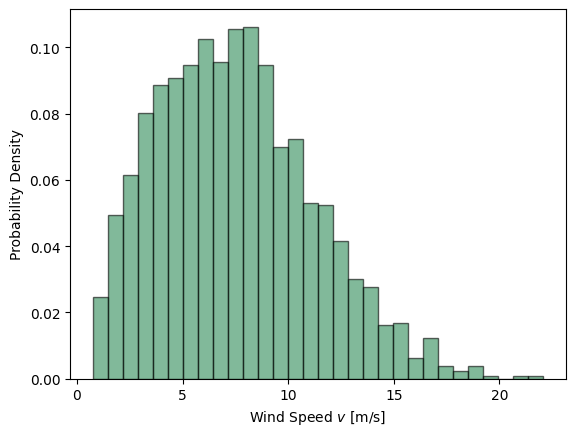

In [71]:
from scipy.stats import weibull_min

# 1. Generate Wind Speed Data (e.g., daily averages in meters/second)
true_shape_k = 2.2      # Typical wind profile (k ~ 2)
true_scale_lam = 8.5    # Solid wind farm location (scale ~ 8.5 m/s)
n_measurements = 365*5    # 5 years of daily data

np.random.seed(42)
# scipy's weibull_min uses 'c' for the shape parameter and 'scale' for lambda
wind_speeds = weibull_min.rvs(c=true_shape_k, scale=true_scale_lam, size=n_measurements)

# Plot the histogram
plt.hist(wind_speeds, bins=30, density=True, alpha=0.6, color='seagreen', edgecolor='black')
plt.xlabel("Wind Speed $v$ [m/s]")
plt.ylabel("Probability Density")
plt.show()
#@title { vertical-output: true}

In [72]:
# 2. Define the PDF wrapper for UnbinnedNLL
def weibull_pdf(v, k, lam):
    # We use scipy's built-in PDF for convenience
    return weibull_min.pdf(v, c=k, scale=lam)

# 3. Create the cost function
nll_wind = UnbinnedNLL(wind_speeds, weibull_pdf)

# 4. Initialize Minuit with starting guesses
# Both shape and scale MUST be strictly positive for the math to work!
m_wind = Minuit(nll_wind, k=1.0, lam=5.0)
m_wind.limits['k'] = (0.001, None)
m_wind.limits['lam'] = (0.001, None)

# 5. Minimize and compute errors
m_wind.migrad()
#@title { vertical-output: true}

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9759                       │              Nfcn = 51               │
│ EDM = 2.12e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │   2.17    │   0.04    │            │            │  0.001  │         │       │
│ 1 │ lam  │   8.48    │   0.10    │            │            │  0.001  │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │       k     lam │
├─────┼─────────────────┤
│   k │ 0.00157  0.0012 │
│ lam │  0.0012  0.0093 │
└─────┴─────────────────┘